In [9]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- CONFIG ----------

# ConvNeXt run tags you have
CONVNEXT_TAGS = [
    "convnext_baseline",
    "convnext_A1_geo",
    "convnext_A2_photo",
    "convnext_A3_norm",
    "convnext_A4_realistic",
    "convnext_A5",   # only if you trained and analyzed A5
]

# ----------------------------

def find_project_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur] + list(cur.parents):
        if (p / "src").is_dir() and (p / "data").is_dir():
            return p
    raise RuntimeError(f"Could not find project root starting from {start}")

cwd = Path.cwd()
PROJECT_ROOT = find_project_root(cwd)
print("CWD         :", cwd)
print("PROJECT_ROOT:", PROJECT_ROOT)

analysis_dir = PROJECT_ROOT / "analysis"
print("Analysis dir:", analysis_dir)


CWD         : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/notebooks
PROJECT_ROOT: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project
Analysis dir: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/analysis


In [10]:
def load_tsne_df(tag: str) -> pd.DataFrame:
    """
    Load t-SNE CSV for a given ConvNeXt run tag.
    Expects: analysis/<tag>_tsne.csv
    """
    path = analysis_dir / f"{tag}_tsne.csv"
    df = pd.read_csv(path)
    print(f"[{tag}] t-SNE df shape:", df.shape)
    return df

def load_test_results_df(tag: str) -> pd.DataFrame:
    """
    Load per-sample test results for a given ConvNeXt run tag.
    Expects: analysis/<tag>_test_results.csv
    """
    path = analysis_dir / f"{tag}_test_results.csv"
    df = pd.read_csv(path)
    print(f"[{tag}] test_results df shape:", df.shape)
    return df


[convnext_baseline] t-SNE df shape: (800, 8)


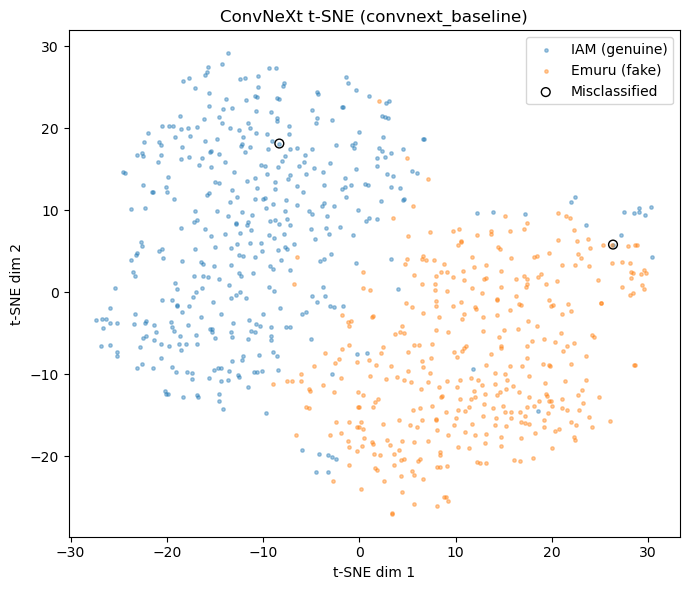

In [12]:
# Choose which variant to visualize
TAG = "convnext_baseline"   # change to A1/A2/A3/A4/A5 as you like

tsne_df = load_tsne_df(TAG)

# Masks
iam_mask = (tsne_df["true_label"].to_numpy() == 0)
emu_mask = (tsne_df["true_label"].to_numpy() == 1)
mis_mask = (tsne_df["true_label"] != tsne_df["pred_label"]).to_numpy()

plt.figure(figsize=(7, 6))

# IAM (genuine)
plt.scatter(
    tsne_df.loc[iam_mask, "tsne_x"],
    tsne_df.loc[iam_mask, "tsne_y"],
    s=6,
    alpha=0.4,
    label="IAM (genuine)",
)

# Emuru (fake)
plt.scatter(
    tsne_df.loc[emu_mask, "tsne_x"],
    tsne_df.loc[emu_mask, "tsne_y"],
    s=6,
    alpha=0.4,
    label="Emuru (fake)",
)

# Misclassified (red circles)
if mis_mask.any():
    plt.scatter(
        tsne_df.loc[mis_mask, "tsne_x"],
        tsne_df.loc[mis_mask, "tsne_y"],
        s=40,
        edgecolors="k",
        facecolors="none",
        linewidths=1.0,
        label="Misclassified",
    )

plt.title(f"ConvNeXt t-SNE ({TAG})")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.legend()
plt.tight_layout()
plt.show()


[convnext_baseline] t-SNE df shape: (800, 8)
[convnext_A4_realistic] t-SNE df shape: (800, 8)
[convnext_A5_noisy] t-SNE df shape: (800, 8)


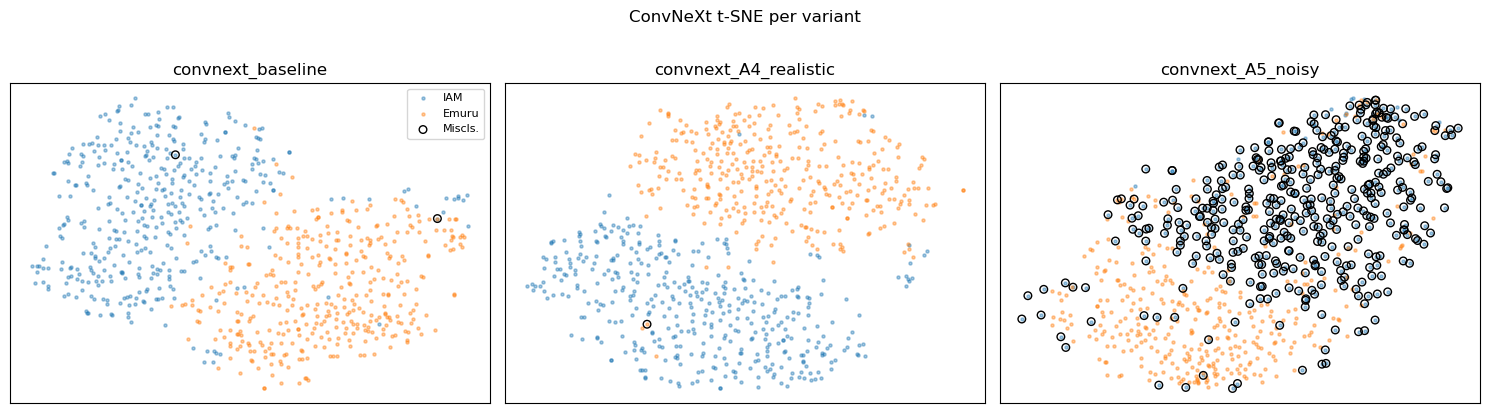

In [13]:
# Pick which tags to show in a grid
TAGS_FOR_GRID = [
    "convnext_baseline",
    "convnext_A4_realistic",
    "convnext_A5_noisy",
]

n = len(TAGS_FOR_GRID)
cols = 3
rows = int(np.ceil(n / cols))

plt.figure(figsize=(5 * cols, 4 * rows))

for i, tag in enumerate(TAGS_FOR_GRID, start=1):
    tsne_df = load_tsne_df(tag)
    iam_mask = (tsne_df["true_label"].to_numpy() == 0)
    emu_mask = (tsne_df["true_label"].to_numpy() == 1)
    mis_mask = (tsne_df["true_label"] != tsne_df["pred_label"]).to_numpy()

    ax = plt.subplot(rows, cols, i)

    ax.scatter(
        tsne_df.loc[iam_mask, "tsne_x"],
        tsne_df.loc[iam_mask, "tsne_y"],
        s=5,
        alpha=0.4,
        label="IAM",
    )
    ax.scatter(
        tsne_df.loc[emu_mask, "tsne_x"],
        tsne_df.loc[emu_mask, "tsne_y"],
        s=5,
        alpha=0.4,
        label="Emuru",
    )
    if mis_mask.any():
        ax.scatter(
            tsne_df.loc[mis_mask, "tsne_x"],
            tsne_df.loc[mis_mask, "tsne_y"],
            s=30,
            edgecolors="k",
            facecolors="none",
            linewidths=1.0,
            label="Miscls.",
        )

    ax.set_title(tag)
    ax.set_xticks([])
    ax.set_yticks([])

    if i == 1:
        ax.legend(fontsize=8)

plt.suptitle("ConvNeXt t-SNE per variant", y=1.02)
plt.tight_layout()
plt.show()


In [14]:
acc_rows = []

for tag in CONVNEXT_TAGS:
    try:
        df_res = load_test_results_df(tag)
    except FileNotFoundError:
        print(f"[{tag}] test_results CSV not found, skipping.")
        continue

    acc = (df_res["true_label"] == df_res["pred_label"]).mean()
    acc_rows.append({"tag": tag, "accuracy": acc})

acc_df = pd.DataFrame(acc_rows)
acc_df = acc_df.sort_values("tag")
acc_df


[convnext_baseline] test_results df shape: (5506, 6)
[convnext_A1_geo] test_results df shape: (5506, 6)
[convnext_A2_photo] test_results df shape: (5506, 6)
[convnext_A3_norm] test_results df shape: (5506, 6)
[convnext_A4_realistic] test_results df shape: (5506, 6)
[convnext_A5] test_results df shape: (5506, 6)


,tag,accuracy
1,convnext_A1_geo,0.999637
2,convnext_A2_photo,0.997821
3,convnext_A3_norm,0.999455
4,convnext_A4_realistic,0.999274
5,convnext_A5,0.999637
0,convnext_baseline,0.999092


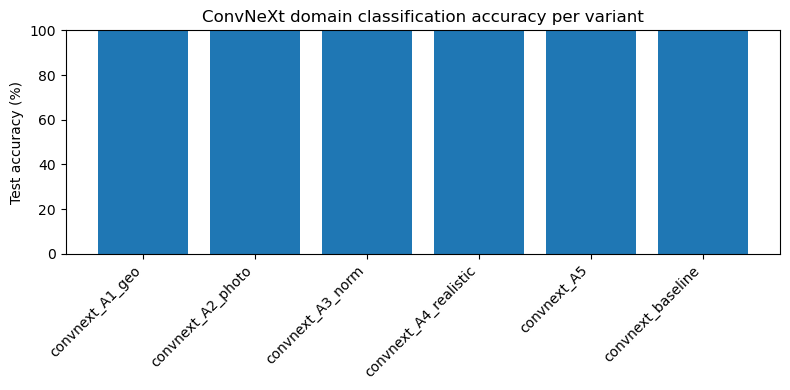

In [15]:
plt.figure(figsize=(8, 4))

plt.bar(
    acc_df["tag"],
    acc_df["accuracy"] * 100.0,
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Test accuracy (%)")
plt.title("ConvNeXt domain classification accuracy per variant")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


In [16]:
rows = []

for tag in CONVNEXT_TAGS:
    try:
        df_res = load_test_results_df(tag)
    except FileNotFoundError:
        continue

    y_true = df_res["true_label"].to_numpy()
    y_pred = df_res["pred_label"].to_numpy()

    mask_iam = (y_true == 0)
    mask_emu = (y_true == 1)

    acc_iam = (y_pred[mask_iam] == 0).mean() if mask_iam.any() else np.nan
    acc_emu = (y_pred[mask_emu] == 1).mean() if mask_emu.any() else np.nan

    rows.append({
        "tag": tag,
        "acc_iam": acc_iam,
        "acc_emuru": acc_emu,
    })

per_class_df = pd.DataFrame(rows).sort_values("tag")
per_class_df


[convnext_baseline] test_results df shape: (5506, 6)
[convnext_A1_geo] test_results df shape: (5506, 6)
[convnext_A2_photo] test_results df shape: (5506, 6)
[convnext_A3_norm] test_results df shape: (5506, 6)
[convnext_A4_realistic] test_results df shape: (5506, 6)
[convnext_A5] test_results df shape: (5506, 6)


,tag,acc_iam,acc_emuru
1,convnext_A1_geo,0.999274,1.000000
2,convnext_A2_photo,0.998910,0.996731
3,convnext_A3_norm,0.999274,0.999637
4,convnext_A4_realistic,0.999637,0.998910
5,convnext_A5,0.999637,0.999637
0,convnext_baseline,0.998184,1.000000


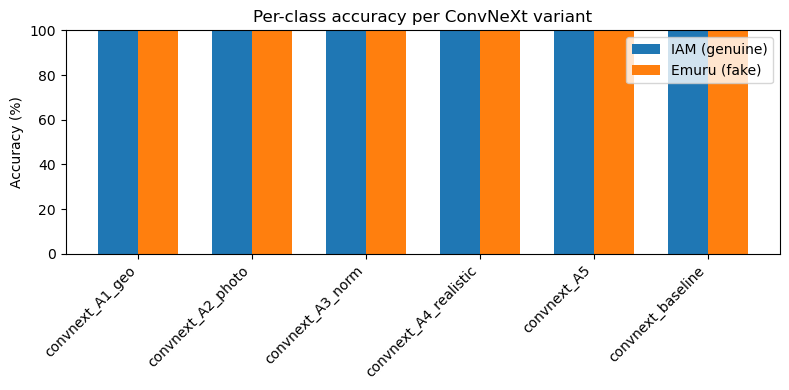

In [17]:
x = np.arange(len(per_class_df))
width = 0.35

plt.figure(figsize=(8, 4))

plt.bar(x - width/2, per_class_df["acc_iam"] * 100.0, width, label="IAM (genuine)")
plt.bar(x + width/2, per_class_df["acc_emuru"] * 100.0, width, label="Emuru (fake)")

plt.xticks(x, per_class_df["tag"], rotation=45, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("Per-class accuracy per ConvNeXt variant")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()
